I used Gemini with the guided learning enabled to help me with understanding, and walking me through the steps to solve everything while asking questions of me and I of it.


In [9]:
from scipy import stats
import numpy as np

In [10]:
#1

#1.1
#N = 100, k=23,
#p_hat = k/N = 23/100 = MLE

#1.2
samples = stats.bernoulli.rvs(0.23, size=100)
var_hat = 0.23*(1-0.23)/100
std_err = np.sqrt(var_hat)
var_hat, std_err

(0.001771, np.float64(0.042083250825001625))

In [12]:
confidence_interval_95 = (0.23 - 1.96*std_err, 0.23 + 1.96*std_err)
confidence_interval_95

(np.float64(0.14751682838299685), np.float64(0.3124831716170032))

In [23]:
#1.3
heads = np.ones(23)
tails = np.zeros(77)

N=100
head23_tail77 = np.concatenate((tails, heads))

bootstrap_means = [np.mean(np.random.choice(head23_tail77, size=N, replace=True)) for _ in range(0, 10000)]

bootstrap_means[:3]

[np.float64(0.24), np.float64(0.26), np.float64(0.19)]

In [26]:
#percentile
confidence_interval_95_percentile = np.percentile(bootstrap_means, [2.5, 97.5])
confidence_interval_95_percentile

array([0.15, 0.32])

In [28]:
#pivotal
p_hat = 0.23
confidence_interval_95_pivotal = (2*p_hat - confidence_interval_95_percentile[1], 2*p_hat - confidence_interval_95_percentile[0])
confidence_interval_95_pivotal

(np.float64(0.14), np.float64(0.31000000000000005))

Personal notes:
MLE
$$\hat{p} = \frac{k}{N} = \frac{23}{100} = 0.23$$

Using central limit theorem
$$\hat{p} \sim \mathcal{N}\left(p, \, \frac{1}{I(p)}\right)$$

 $I(p)$ is the Fisher Information for $N$ observations.

 For $N$ Bernoulli trials, the Fisher Information is given by:$$I(p) = \frac{N}{p(1-p)}$$

 $$\widehat{\text{Var}}(\hat{p}) = \frac{1}{I(\hat{p})} = \frac{\hat{p}(1-\hat{p})}{N}$$


 $$\text{CI} = \hat{p} \pm z_{0.975} \times \text{SE}$$

 $\text{For CI 95\%}: z_{0.975} \approx 1.96$.

# Ex2

2.1
Likelihood fun is $L(a,b)$ => joint PDF

$X \sim \text{Uniform}(a, b)$, its PDF is:$$f(x; a, b) = \begin{cases} \frac{1}{b - a} & \text{if } a \le x \le b \\ 0 & \text{otherwise} \end{cases}$$

personal note: To maximize $L(a,b)$, need to make denominator really small. To minimize the length of the interval $(b-a)$, we need to have values of $a$ and $b$ to be really close to one another, but not $0$. $a$ can be as large as $x$, but no larger, and $b$ can be as small as $x$, but no smaller.

$$\hat{a} = \min(X_1, X_2, X_3, X_4) = X_{(1)}$$

$$\hat{b} = \max(X_1, X_2, X_3, X_4) = X_{(4)}$$

The MLEs are $\hat{a} = X_{(1)}$ and $\hat{b} = X_{(4)}$

2.2
$\int x f(x) \mathrm{d}x$ gives us the expected value or mean $\mathbb{E}[X]$

$$\tau = \int_{a}^{b} x \left(\frac{1}{b - a}\right) \mathrm{d}x = \frac{1}{b - a} \int_{a}^{b} x \mathrm{d}x$$

$$\int_{a}^{b} x \mathrm{d}x =  \frac{b^2-a^2}{2}$$
$$= \frac{(b-a)(b+a)}{2} $$
$$\tau = \frac{1}{b - a} * \frac{(b-a)(b+a)}{2} = \frac{b+a}{2} $$

$\tau = \frac{a + b}{2}$ represents the expected value $\mathbb{E}[X]$

personal note: by the invariance property of the MLE (if $\hat{\theta}$ is the MLE of $\theta$, then the MLE of a function $g(\theta)$ is simply $g(\hat{\theta})$):

$$\text MLE \hat{\tau} = \frac{\hat{b}+\hat{a}}{2}  = \frac{X_{(4)} + X_{(1)}}{2}$$

# Ex3

personal note: Method of Moments is a technique for estimating unknown parameters in a probability distribution. Equate the theoretical population moment $E[X^k]$ (the expected value based on the probability distribution) to the corresponding sample moment $\frac{1}{n} \sum_{i=1}^n X_i^k$ (calculated from observed data).

---

Theoretical moment: $E[X] = \lambda$

Sample moment: The sample mean $\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$


$$\text{Theoretical Moment } E[X] = \text{Sample Moment } \bar{X}$$

$$E[X] = \lambda = \bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i = \frac{1}{n} * n\lambda = \hat{\lambda}$$

$$\hat{\lambda} = \bar{X}$$

personal note: The Method of Moments estimator for $\lambda$ is the sample mean


# Ex4

personal note: To find the Maximum Likelihood Estimator (MLE) for $\lambda$ when $X_1, \ldots, X_n \sim \text{Poisson}(\lambda)$, we follow a standard four-step procedure: write the probability mass function, construct the likelihood function, take the natural logarithm (log-likelihood), and maximize with respect to $\lambda$.

PMF:
$$P(X_i = x_i) = \frac{e^{-\lambda} \lambda^{x_i}}{x_i!}$$

---

Likelihood fun (i.i.d):
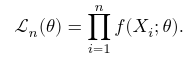

$$L(\lambda) = \prod_{i=1}^{n} \frac{e^{-\lambda} \lambda^{x_i}}{x_i!}$$

$$= L(\lambda) = \frac{e^{-n\lambda} \lambda^{\sum_{i=1}^n x_i}}{\prod_{i=1}^n x_i!}$$

---
personal note: log is good for simplifying the expression. preserves maximum (value of $\lambda$ that maximizes $\ln L(\lambda)$ is identical to the value that maximizes $L(\lambda)$. avoids arithmetic underflow.

Log likelihood fun: 

$$\ell(\lambda) = \ln L(\lambda) = \ln \left( e^{-n\lambda} \lambda^{\sum_{i=1}^n x_i} \right) - \ln \left( \prod_{i=1}^n x_i! \right)$$

 logarithmic properties $\ln(ab) = \ln(a) + \ln(b)$ and $\ln(a^b) = b \ln(a)$

 $$\ell(\lambda) = \ln \left( e^{-n\lambda} \right) + \ln \left(\lambda^{\sum_{i=1}^n x_i} \right) - \ln \left( \prod_{i=1}^n x_i! \right)$$

$$ = -n\lambda \ln \left(e\right) + \left (\sum_{i=1}^n x_i \right) \ln \left(\lambda \right) - \ln \left( \prod_{i=1}^n x_i! \right)$$

---
Maximize the Log-Likelihood Function
personal note: first derivative for finding turning point of the log likelihood curve. second derivative measures curvature of the fun to check what type of critical point it is. If $\frac{d^2\ell}{d\lambda^2} < 0$, then is concave down, maximum. If $\frac{d^2\ell}{d\lambda^2} > 0$, concave up, minimum.


notes: derivatives $\ln \left(e\right) = 0, \ln \left(\lambda \right) = \frac{1}{\lambda} $
$$\frac{d\ell}{d\lambda} = -n + \frac{\sum_{i=1}^n x_i}{\lambda}$$

derivative equal to zero to find the critical point $\hat{\lambda}$:$$-n + \frac{\sum_{i=1}^n x_i}{\hat{\lambda}} = 0$$

$$\frac{\sum_{i=1}^n x_i}{\hat{\lambda}} = n$$

$$\hat{\lambda} = \frac{1}{n} \sum_{i=1}^n x_i = \bar{X}$$

confirm this critical point is a maximum:$$\frac{d^2\ell}{d\lambda^2} = -\frac{\sum_{i=1}^n x_i}{\lambda^2}$$

---
$$\hat{\lambda}_{\text{MLE}} = \bar{X}$$